____
# Aberant values in SWOT 250m SLA



In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    U,
)
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import (
    dataset_coloc_combs,
    DRIFTER,
    ALTI,
    WD,
    prepared_wd,
    plot_exemple,
    compute_mean_square,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal']),
 dict_keys(['era5']))

nofilter__swot250naive_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
7.782537467634771
9.058396582539707
7.547757984811021
8.099277257108316


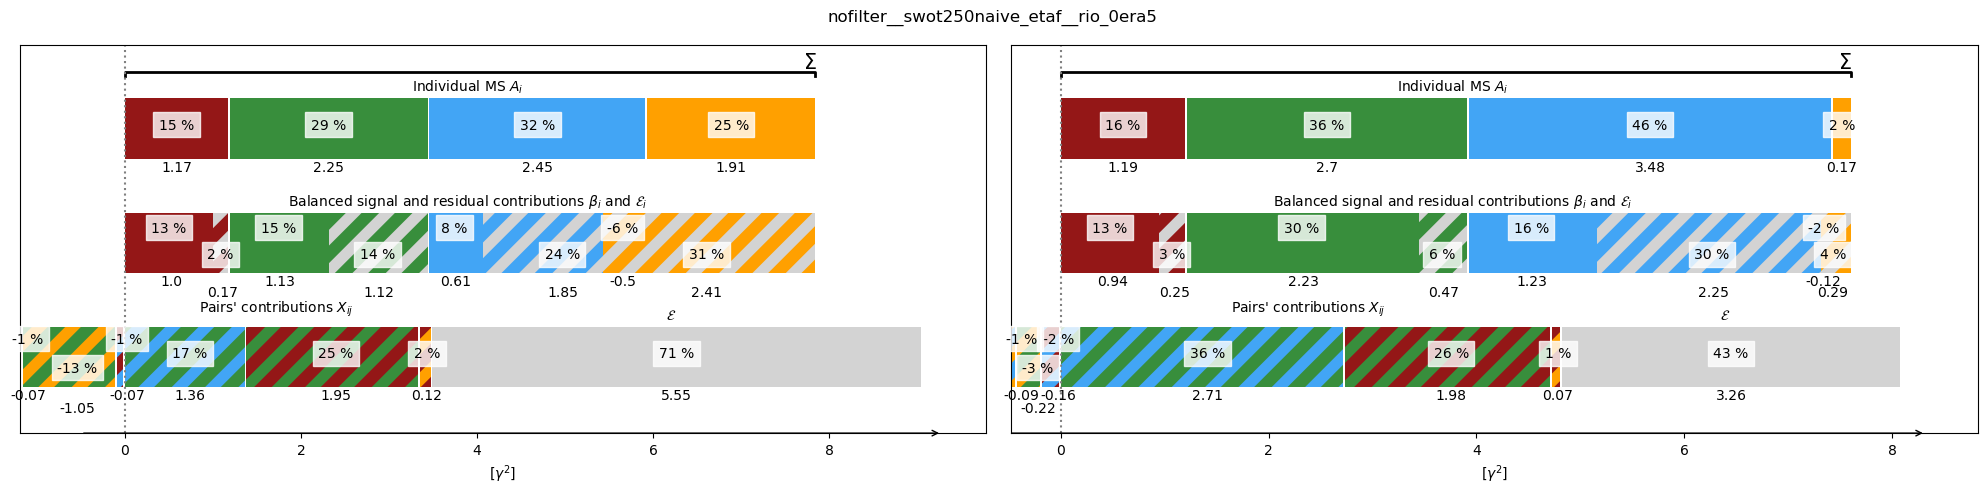

In [6]:
# dfef = pd.read_csv(os.path.join(zarr_dir, 'editing_flags_250m.csv')).set_index('row_number')
dfc = pd.read_csv(ALTI["swot250naive"])[
    ["row_number", "cvl_distance_to_coast"]
].set_index("row_number")
dfa = dfc
# dfa = pd.concat([dfef, dfc], axis=1)
dsa = dfa.to_xarray()

comb_list = [
    dict(
        drifter_key="nofilter",
        alti_key="swot250naive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    ),
]

DS = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
# DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth == 0, drop=True)
DSD = DS.where(DS.depth == 15, drop=True)

ds = compute_mean_square(DSD) / U2
df = ds.to_dataframe()
for c in ds.id_comb.values:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir="e")
    synthetic_figure(df.loc[c], axs[1], dir="n")
    fig.suptitle(c)
    fig.tight_layout()

# df = xr.merge([DSS.isel(id_comb=0), dsa]).to_dataframe()

In [7]:
# dfef = pd.read_csv(os.path.join(zarr_dir, 'editing_flags_250m.csv')).set_index('row_number')
dfc = pd.read_csv(ALTI["swot250naive"])[
    ["row_number", "cvl_distance_to_coast"]
].set_index("row_number")
dfa = dfc
# dfa = pd.concat([dfef, dfc], axis=1)
dsa = dfa.to_xarray()

comb_list = [
    dict(
        drifter_key="nofilter",
        alti_key="swot250naive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    ),
]

DS = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=False)
# DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth == 0, drop=True)
DSD = DS.where(DS.depth == 15, drop=True)


# df = xr.merge([DSS.isel(id_comb=0), dsa]).to_dataframe()

nofilter__swot250naive_etaf__rio_0era5


In [8]:
DSD

<xarray.Dataset> Size: 49MB
Dimensions:        (id_comb: 1, row_number: 149787)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 1MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 1MB 4.812 4.812 ... 2.415 2.414
    latitude       (id_comb, row_number) float64 1MB 42.22 42.22 ... 39.79 39.79
    pass_number    (id_comb, row_number) int64 1MB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 1MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) int64 1MB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 1MB '300534060315840' ... '30...
    drifter_type   (id_comb, row_number) object 1MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth          (id_comb, row_number) int64 1MB 15 15 15 15 ... 15 15 15 15
    phi            (id_comb, row_number) float64 1MB 0.2354 0.237 ... 2.917
  * row_number     (row_number) int64 1MB 0 1 2 3 ... 376720 376721 376722
  * id_comb        (id_comb) <U38 152B 'nofilter__swot250naive_etaf__rio_0era5'
Data variables: (12/30)
    sume           (id_comb, row_number) float64 1MB 2.805e-05 ... 1.247e-06
    acce           (id_comb, row_number) float64 1MB 6.386e-06 ... -1.995e-06
    exce_acc       (id_comb, row_number) float64 1MB 2.166e-05 ... 3.241e-06
    core           (id_comb, row_number) float64 1MB -1.001e-05 ... -1.024e-05
    exce_cor       (id_comb, row_number) float64 1MB 3.806e-05 ... 1.149e-05
    ggde           (id_comb, row_number) float64 1MB 5.984e-06 ... 1.433e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 1MB -7.476e-11 ... -1.039e-10
    prodn_acc_ggd  (id_comb, row_number) float64 1MB -2.429e-10 ... -3.703e-10
    prodn_acc_wd   (id_comb, row_number) float64 1MB -9.676e-11 ... -4.653e-11
    prodn_cor_ggd  (id_comb, row_number) float64 1MB 1.238e-10 ... 5.821e-10
    prodn_cor_wd   (id_comb, row_number) float64 1MB 4.934e-11 ... 7.314e-11
    prodn_ggd_wd   (id_comb, row_number) float64 1MB 1.603e-10 ... 2.608e-10

In [9]:
DSD

<xarray.Dataset> Size: 49MB
Dimensions:        (id_comb: 1, row_number: 149787)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 1MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 1MB 4.812 4.812 ... 2.415 2.414
    latitude       (id_comb, row_number) float64 1MB 42.22 42.22 ... 39.79 39.79
    pass_number    (id_comb, row_number) int64 1MB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 1MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) int64 1MB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 1MB '300534060315840' ... '30...
    drifter_type   (id_comb, row_number) object 1MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth          (id_comb, row_number) int64 1MB 15 15 15 15 ... 15 15 15 15
    phi            (id_comb, row_number) float64 1MB 0.2354 0.237 ... 2.917
  * row_number     (row_number) int64 1MB 0 1 2 3 ... 376720 376721 376722
  * id_comb        (id_comb) <U38 152B 'nofilter__swot250naive_etaf__rio_0era5'
Data variables: (12/30)
    sume           (id_comb, row_number) float64 1MB 2.805e-05 ... 1.247e-06
    acce           (id_comb, row_number) float64 1MB 6.386e-06 ... -1.995e-06
    exce_acc       (id_comb, row_number) float64 1MB 2.166e-05 ... 3.241e-06
    core           (id_comb, row_number) float64 1MB -1.001e-05 ... -1.024e-05
    exce_cor       (id_comb, row_number) float64 1MB 3.806e-05 ... 1.149e-05
    ggde           (id_comb, row_number) float64 1MB 5.984e-06 ... 1.433e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 1MB -7.476e-11 ... -1.039e-10
    prodn_acc_ggd  (id_comb, row_number) float64 1MB -2.429e-10 ... -3.703e-10
    prodn_acc_wd   (id_comb, row_number) float64 1MB -9.676e-11 ... -4.653e-11
    prodn_cor_ggd  (id_comb, row_number) float64 1MB 1.238e-10 ... 5.821e-10
    prodn_cor_wd   (id_comb, row_number) float64 1MB 4.934e-11 ... 7.314e-11
    prodn_ggd_wd   (id_comb, row_number) float64 1MB 1.603e-10 ... 2.608e-10

__________________
# PB on synthetic figures

56.46725189859654
58.064673572026166
118.09599410936585
119.62168662489866


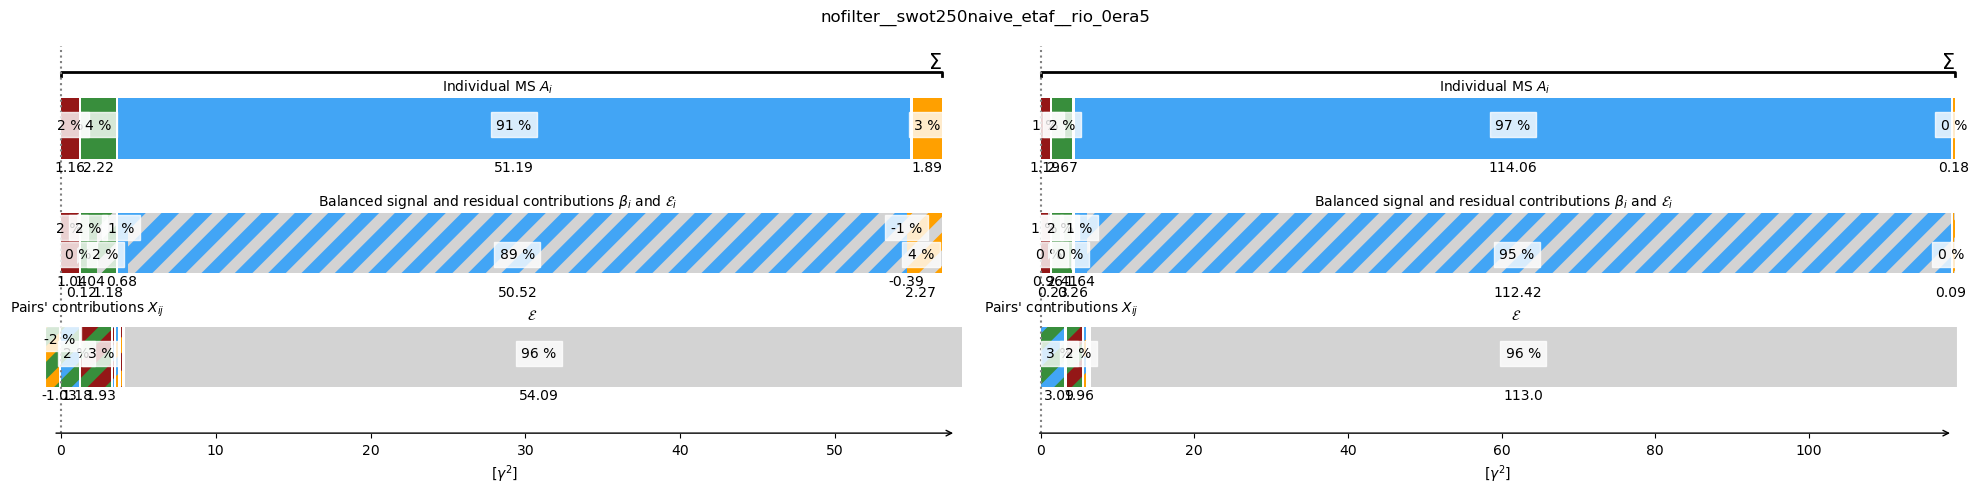

In [10]:
ds = compute_mean_square(DSD) / U2
df = ds.to_dataframe()
for c in ds.id_comb.values:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir="e")
    synthetic_figure(df.loc[c], axs[1], dir="n")
    fig.suptitle(c)
    fig.tight_layout()
#    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

__________________
# PB = Some aberant values considerably change the residual MS

- Where are these abusive values ? South of Minorca or south of the french coast
  
- Can they be related to :
    - SWOT ? yes for the 250m
    - editing flags ? No
    - distance to coast ? They are effectively near the coast
    - Are they visible on swot 250m product velocities ?

In [13]:
df = xr.merge([DS.isel(id_comb=0), dsa]).to_dataframe()
# df =df/np.sqrt(U2)

In [48]:
# SELECT OUTLIERS
a = 3e-4
# dfpb = df.where((abs(df.sume)>a) | (abs(df.sumn)>a)).dropna()
# len(dfpb)

# df290 = dfpb.where(dfpb.drifter_id =='290')
# df460 = dfpb.where(dfpb.drifter_id =='300534064300460')
# df675 = dfpb.where(dfpb.drifter_id =='0-4388675')
dfpb = df.where((abs(df.ggde) > a) | (abs(df.ggdn) > a)).dropna()

NameError: name 'df290' is not defined

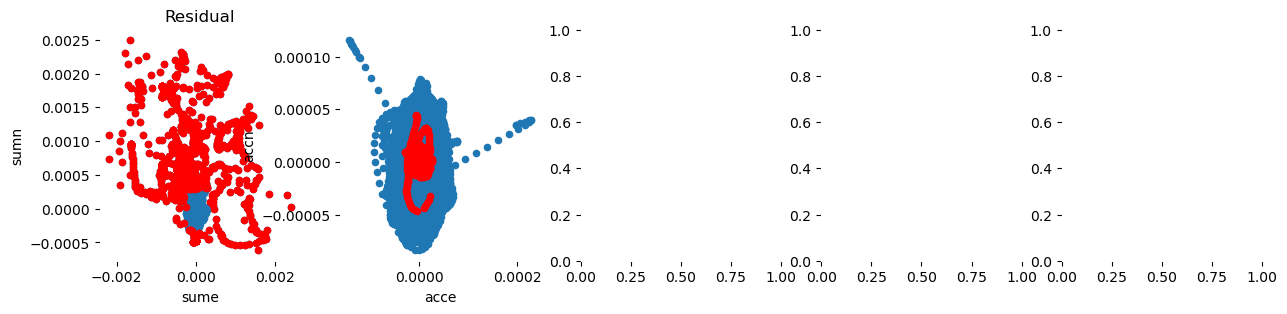

In [49]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
axs = axs.flatten()
ax = axs[0]
df.plot.scatter("sume", "sumn", ax=ax)
dfpb.plot.scatter("sume", "sumn", ax=ax, c="r")
# df290.plot.scatter('sume', 'sumn', ax=ax, c='g', marker='+')
# df460.plot.scatter('sume', 'sumn', ax=ax, c='b', marker='+')
# df675.plot.scatter('sume', 'sumn', ax=ax, c='orange', marker='+')
# dfggd.plot.scatter('sume', 'sumn', ax=ax, c='magenta', marker='+')
ax.set_title("Residual")

ax = axs[1]
df.plot.scatter("acce", "accn", ax=ax)
dfpb.plot.scatter("acce", "accn", ax=ax, c="r")
df290.plot.scatter("acce", "accn", ax=ax, c="g", marker="+")
df460.plot.scatter("acce", "accn", ax=ax, c="b", marker="+")
df675.plot.scatter("acce", "accn", ax=ax, c="orange", marker="+")
dfggd.plot.scatter("acce", "accn", ax=ax, c="magenta", marker="+")
ax.set_title("Lagrangian acceleration")

ax = axs[2]
df.plot.scatter("core", "corn", ax=ax)
dfpb.plot.scatter("core", "corn", ax=ax, c="r")
df290.plot.scatter("core", "corn", ax=ax, c="g", marker="+")
df460.plot.scatter("core", "corn", ax=ax, c="b", marker="+")
df675.plot.scatter("core", "corn", ax=ax, c="orange", marker="+")
dfggd.plot.scatter("core", "corn", ax=ax, c="magenta", marker="+")
ax.set_title("Coriolis acceleration")

ax = axs[3]
df.plot.scatter("ggde", "ggdn", ax=ax)
dfpb.plot.scatter("ggde", "ggdn", ax=ax, c="r")
df290.plot.scatter("ggde", "ggdn", ax=ax, c="g", marker="+")
df460.plot.scatter("ggde", "ggdn", ax=ax, c="b", marker="+")
df675.plot.scatter("ggde", "ggdn", ax=ax, c="orange", marker="+")
dfggd.plot.scatter("ggde", "ggdn", ax=ax, c="magenta", marker="+")
ax.set_title("Pressure gradient")

ax = axs[4]
df.plot.scatter("wde", "wdn", ax=ax)
dfpb.plot.scatter("wde", "wdn", ax=ax, c="r")
df290.plot.scatter("wde", "wdn", ax=ax, c="g", marker="+")
df460.plot.scatter("wde", "wdn", ax=ax, c="b", marker="+")
df675.plot.scatter("wde", "wdn", ax=ax, c="orange", marker="+")
dfggd.plot.scatter("wde", "wdn", ax=ax, c="magenta", marker="+")
ax.set_title("Wind")


for ax in axs:
    ax.grid()

fig.tight_layout()

In [ ]:
dfpb

In [ ]:
fig = plt.figure(figsize=(12, 7), frameon=False)

ax = fig.add_subplot(
    121, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean())
)
# a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [2, 6.1, 36.5, 42]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform=crs, c="r")
ax.set_extent(bbox)
ax.add_feature(
    cfeature.LAND,
)

gl = ax.gridlines(
    draw_labels=True,
)
gl.xlabels_top = False
gl.ylabels_right = False


ax = fig.add_subplot(
    122, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean())
)
# a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [3.75, 4, 39.8, 40.05]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform=crs, c="r")
ax.set_extent(bbox)
ax.add_feature(
    cfeature.LAND,
)

gl = ax.gridlines(
    draw_labels=True,
)
gl.xlabels_top = False
gl.ylabels_right = False

In [50]:
idpbswot = dfpb.drifter_id.unique()
tmin = [dfpb[(dfpb.drifter_id == id_)].datetime.min() for id_ in idpbswot]
tmax = [dfpb[(dfpb.drifter_id == id_)].datetime.max() for id_ in idpbswot]

In [45]:
idpbswot

array(['0-4367707', '300534062472380', '300534062474750', '4388938'],
      dtype=object)

In [46]:
tmax

[Timestamp('2023-04-23 18:40:00'),
 Timestamp('2023-04-30 20:40:00'),
 Timestamp('2023-05-25 03:10:00'),
 Timestamp('2023-05-30 23:50:00')]

In [47]:
tmin

[Timestamp('2023-04-23 18:40:00'),
 Timestamp('2023-04-27 22:20:00'),
 Timestamp('2023-05-05 02:30:00'),
 Timestamp('2023-05-30 23:10:00')]

In [51]:
df[(df.drifter_id == idpbswot[i]) & (df.datetime >= tmin[i]) & (df.datetime <= tmax[i])]

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,wdn,excn_wd,prodn_acc_cor,prodn_acc_ggd,prodn_acc_wd,prodn_cor_ggd,prodn_cor_wd,prodn_ggd_wd,id_comb,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
54047.0,2023-04-23 18:40:00,4.969917,43.315392,3.0,0 days 01:36:27.404650304,500.0,0-4367707,CARTHE,0.0,0.241446,...,0.000002,0.000028,-5.256642e-11,-1.476236e-10,-1.421492e-11,2.179866e-10,2.099029e-11,5.894758e-11,nofilter__swot250naive_etaf__rio_0era5,5000.0


In [52]:
def remove_pb_swot(df):
    for i in range(len(idpbswot)):
        pb = (
            (df.drifter_id == idpbswot[i])
            & (df.datetime >= tmin[i])
            & (df.datetime <= tmax[i])
        )
        df = df[~pb]
    return df


dfr = remove_pb_swot(df)

In [53]:
dfr

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,wdn,excn_wd,prodn_acc_cor,prodn_acc_ggd,prodn_acc_wd,prodn_cor_ggd,prodn_cor_wd,prodn_ggd_wd,id_comb,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
0.0,2023-04-01 11:50:00,4.811970,42.220893,3.0,0 days 11:52:32.696536,478.0,300534060315840,SVP,15.0,0.235430,...,0.000008,0.000014,-7.476347e-11,-2.428539e-10,-9.675981e-11,1.238431e-10,4.934256e-11,1.602793e-10,nofilter__swot250naive_etaf__rio_0era5,114000.000000
1.0,2023-04-01 12:00:00,4.812432,42.221430,3.0,0 days 11:42:32.696536,478.0,300534060315840,SVP,15.0,0.236994,...,0.000008,0.000012,-7.586256e-11,-2.044126e-10,-9.312012e-11,1.142610e-10,5.205158e-11,1.402537e-10,nofilter__swot250naive_etaf__rio_0era5,113940.490247
2.0,2023-04-01 12:10:00,4.812916,42.221930,3.0,0 days 11:32:32.696536,478.0,300534060315840,SVP,15.0,0.237373,...,0.000008,0.000013,-7.464552e-11,-1.869282e-10,-8.600817e-11,1.149458e-10,5.288808e-11,1.324430e-10,nofilter__swot250naive_etaf__rio_0era5,113920.969919
3.0,2023-04-01 12:20:00,4.813418,42.222394,3.0,0 days 11:22:32.696536,478.0,300534060315840,SVP,15.0,0.237699,...,0.000008,0.000012,-7.118152e-11,-1.563976e-10,-7.782181e-11,1.067020e-10,5.309379e-11,1.166558e-10,nofilter__swot250naive_etaf__rio_0era5,113758.848726
4.0,2023-04-01 12:30:00,4.813933,42.222825,3.0,0 days 11:12:32.696536,478.0,300534060315840,SVP,15.0,0.237638,...,0.000007,0.000012,-6.561802e-11,-1.261431e-10,-6.868938e-11,9.687014e-11,5.274921e-11,1.014043e-10,nofilter__swot250naive_etaf__rio_0era5,113572.617338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376718.0,2023-07-10 06:10:00,2.417786,39.788394,16.0,0 days 11:13:38.131544384,577.0,300534060015760,SVP,15.0,2.916550,...,-0.000006,-0.000051,-7.199245e-11,-2.794841e-10,-3.948085e-11,5.265085e-10,7.437632e-11,2.887386e-10,nofilter__swot250naive_etaf__rio_0era5,13063.572008
376719.0,2023-07-10 06:20:00,2.416881,39.788885,16.0,0 days 11:23:38.131544384,577.0,300534060015760,SVP,15.0,2.916306,...,-0.000006,-0.000054,-8.759432e-11,-3.542132e-10,-4.514421e-11,5.893676e-10,7.511446e-11,3.037473e-10,nofilter__swot250naive_etaf__rio_0era5,13245.524314
376720.0,2023-07-10 06:30:00,2.415948,39.789399,16.0,0 days 11:33:38.131544384,577.0,300534060015760,SVP,15.0,2.916648,...,-0.000006,-0.000055,-9.825170e-11,-3.983133e-10,-4.800123e-11,6.230538e-10,7.508501e-11,3.043953e-10,nofilter__swot250naive_etaf__rio_0era5,13765.673243


In [54]:
df

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi,...,wdn,excn_wd,prodn_acc_cor,prodn_acc_ggd,prodn_acc_wd,prodn_cor_ggd,prodn_cor_wd,prodn_ggd_wd,id_comb,cvl_distance_to_coast
row_number,,,,,,,,,,,,,,,,,,,,,
0.0,2023-04-01 11:50:00,4.811970,42.220893,3.0,0 days 11:52:32.696536,478.0,300534060315840,SVP,15.0,0.235430,...,0.000008,0.000014,-7.476347e-11,-2.428539e-10,-9.675981e-11,1.238431e-10,4.934256e-11,1.602793e-10,nofilter__swot250naive_etaf__rio_0era5,114000.000000
1.0,2023-04-01 12:00:00,4.812432,42.221430,3.0,0 days 11:42:32.696536,478.0,300534060315840,SVP,15.0,0.236994,...,0.000008,0.000012,-7.586256e-11,-2.044126e-10,-9.312012e-11,1.142610e-10,5.205158e-11,1.402537e-10,nofilter__swot250naive_etaf__rio_0era5,113940.490247
2.0,2023-04-01 12:10:00,4.812916,42.221930,3.0,0 days 11:32:32.696536,478.0,300534060315840,SVP,15.0,0.237373,...,0.000008,0.000013,-7.464552e-11,-1.869282e-10,-8.600817e-11,1.149458e-10,5.288808e-11,1.324430e-10,nofilter__swot250naive_etaf__rio_0era5,113920.969919
3.0,2023-04-01 12:20:00,4.813418,42.222394,3.0,0 days 11:22:32.696536,478.0,300534060315840,SVP,15.0,0.237699,...,0.000008,0.000012,-7.118152e-11,-1.563976e-10,-7.782181e-11,1.067020e-10,5.309379e-11,1.166558e-10,nofilter__swot250naive_etaf__rio_0era5,113758.848726
4.0,2023-04-01 12:30:00,4.813933,42.222825,3.0,0 days 11:12:32.696536,478.0,300534060315840,SVP,15.0,0.237638,...,0.000007,0.000012,-6.561802e-11,-1.261431e-10,-6.868938e-11,9.687014e-11,5.274921e-11,1.014043e-10,nofilter__swot250naive_etaf__rio_0era5,113572.617338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376718.0,2023-07-10 06:10:00,2.417786,39.788394,16.0,0 days 11:13:38.131544384,577.0,300534060015760,SVP,15.0,2.916550,...,-0.000006,-0.000051,-7.199245e-11,-2.794841e-10,-3.948085e-11,5.265085e-10,7.437632e-11,2.887386e-10,nofilter__swot250naive_etaf__rio_0era5,13063.572008
376719.0,2023-07-10 06:20:00,2.416881,39.788885,16.0,0 days 11:23:38.131544384,577.0,300534060015760,SVP,15.0,2.916306,...,-0.000006,-0.000054,-8.759432e-11,-3.542132e-10,-4.514421e-11,5.893676e-10,7.511446e-11,3.037473e-10,nofilter__swot250naive_etaf__rio_0era5,13245.524314
376720.0,2023-07-10 06:30:00,2.415948,39.789399,16.0,0 days 11:33:38.131544384,577.0,300534060015760,SVP,15.0,2.916648,...,-0.000006,-0.000055,-9.825170e-11,-3.983133e-10,-4.800123e-11,6.230538e-10,7.508501e-11,3.043953e-10,nofilter__swot250naive_etaf__rio_0era5,13765.673243


# Check for SWOT outliers
## Visualization figures

In [57]:
from diagnosis import select_nearest_swot_coloc

dfpb_ = select_nearest_swot_coloc(dfpb)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

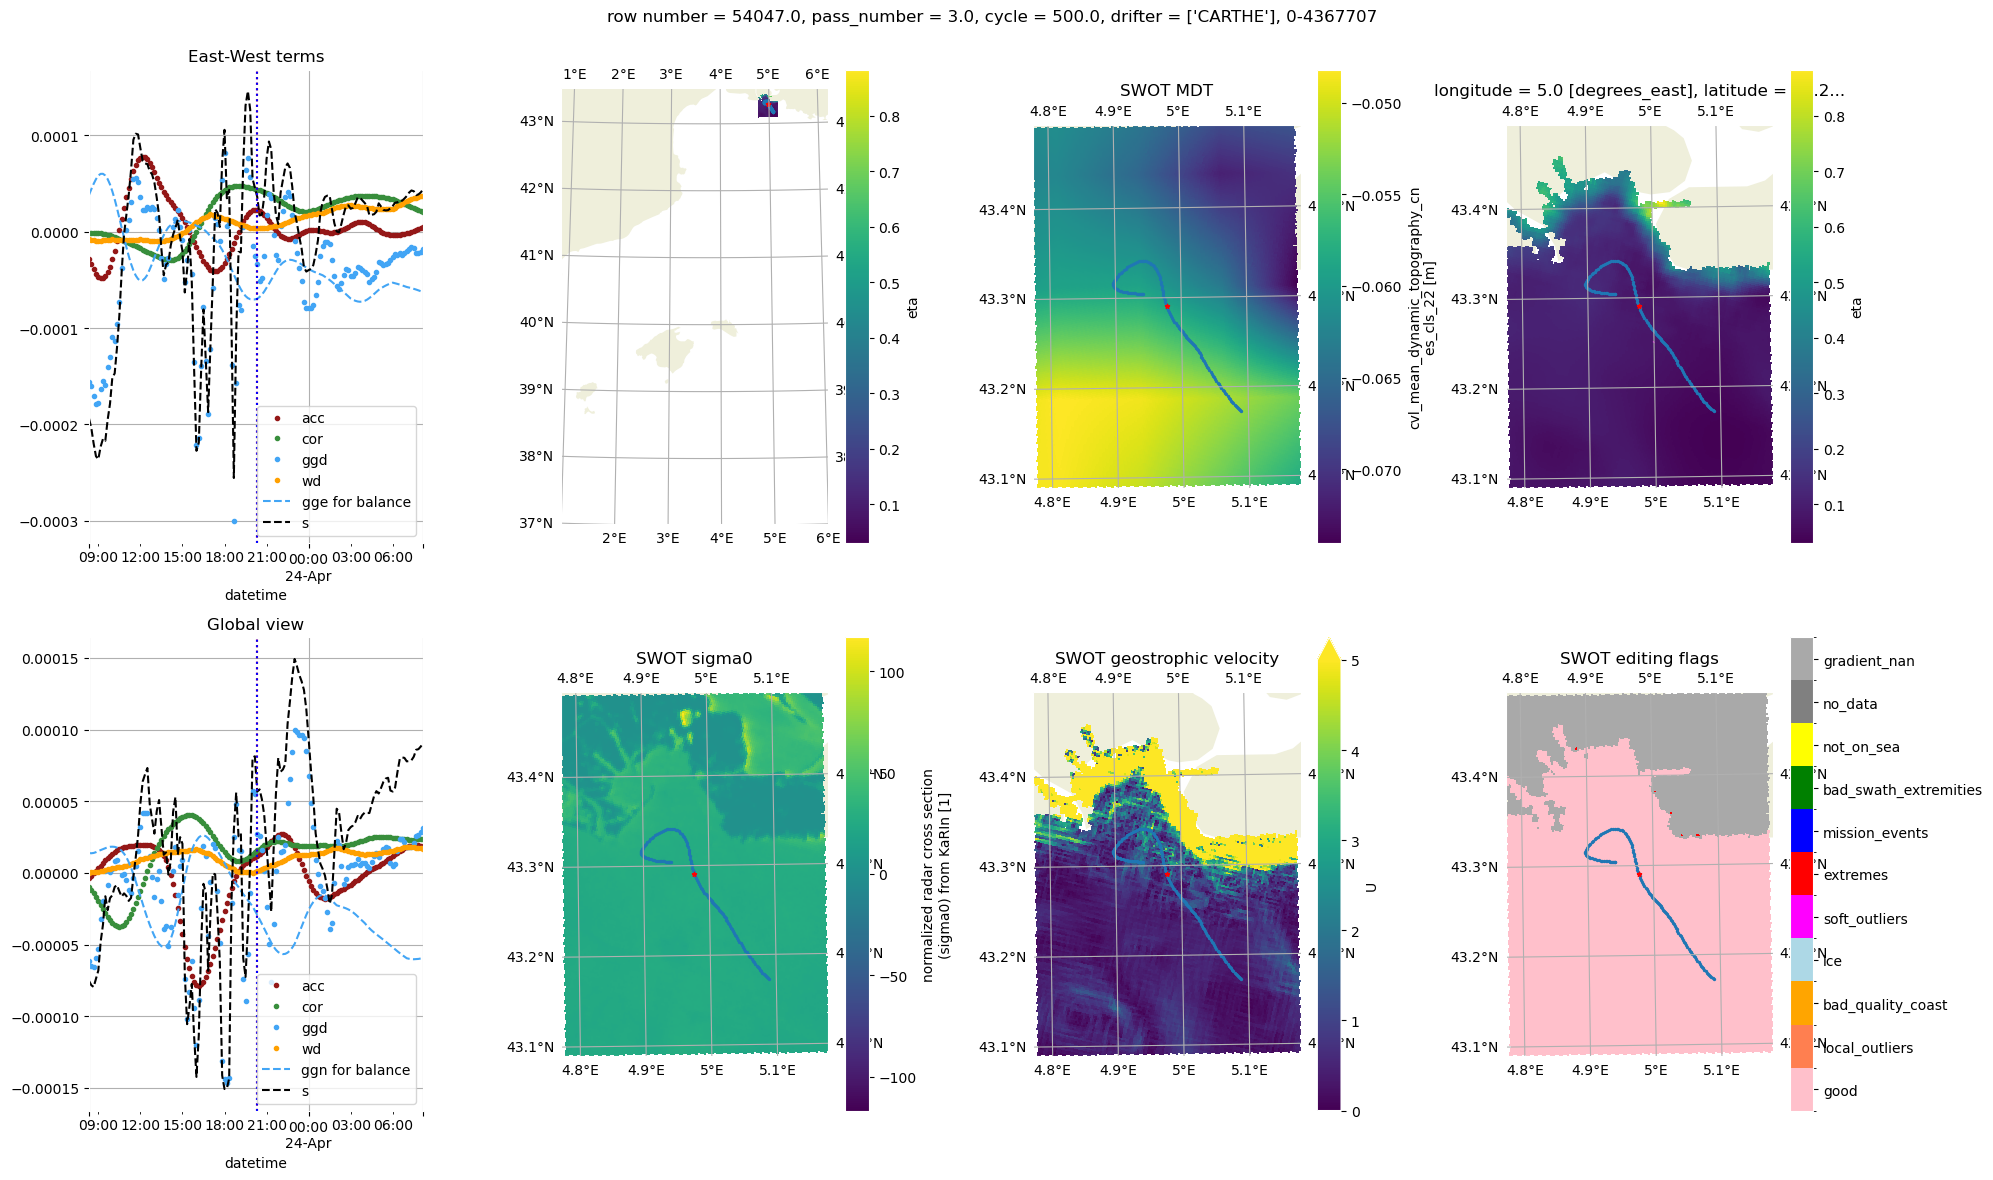

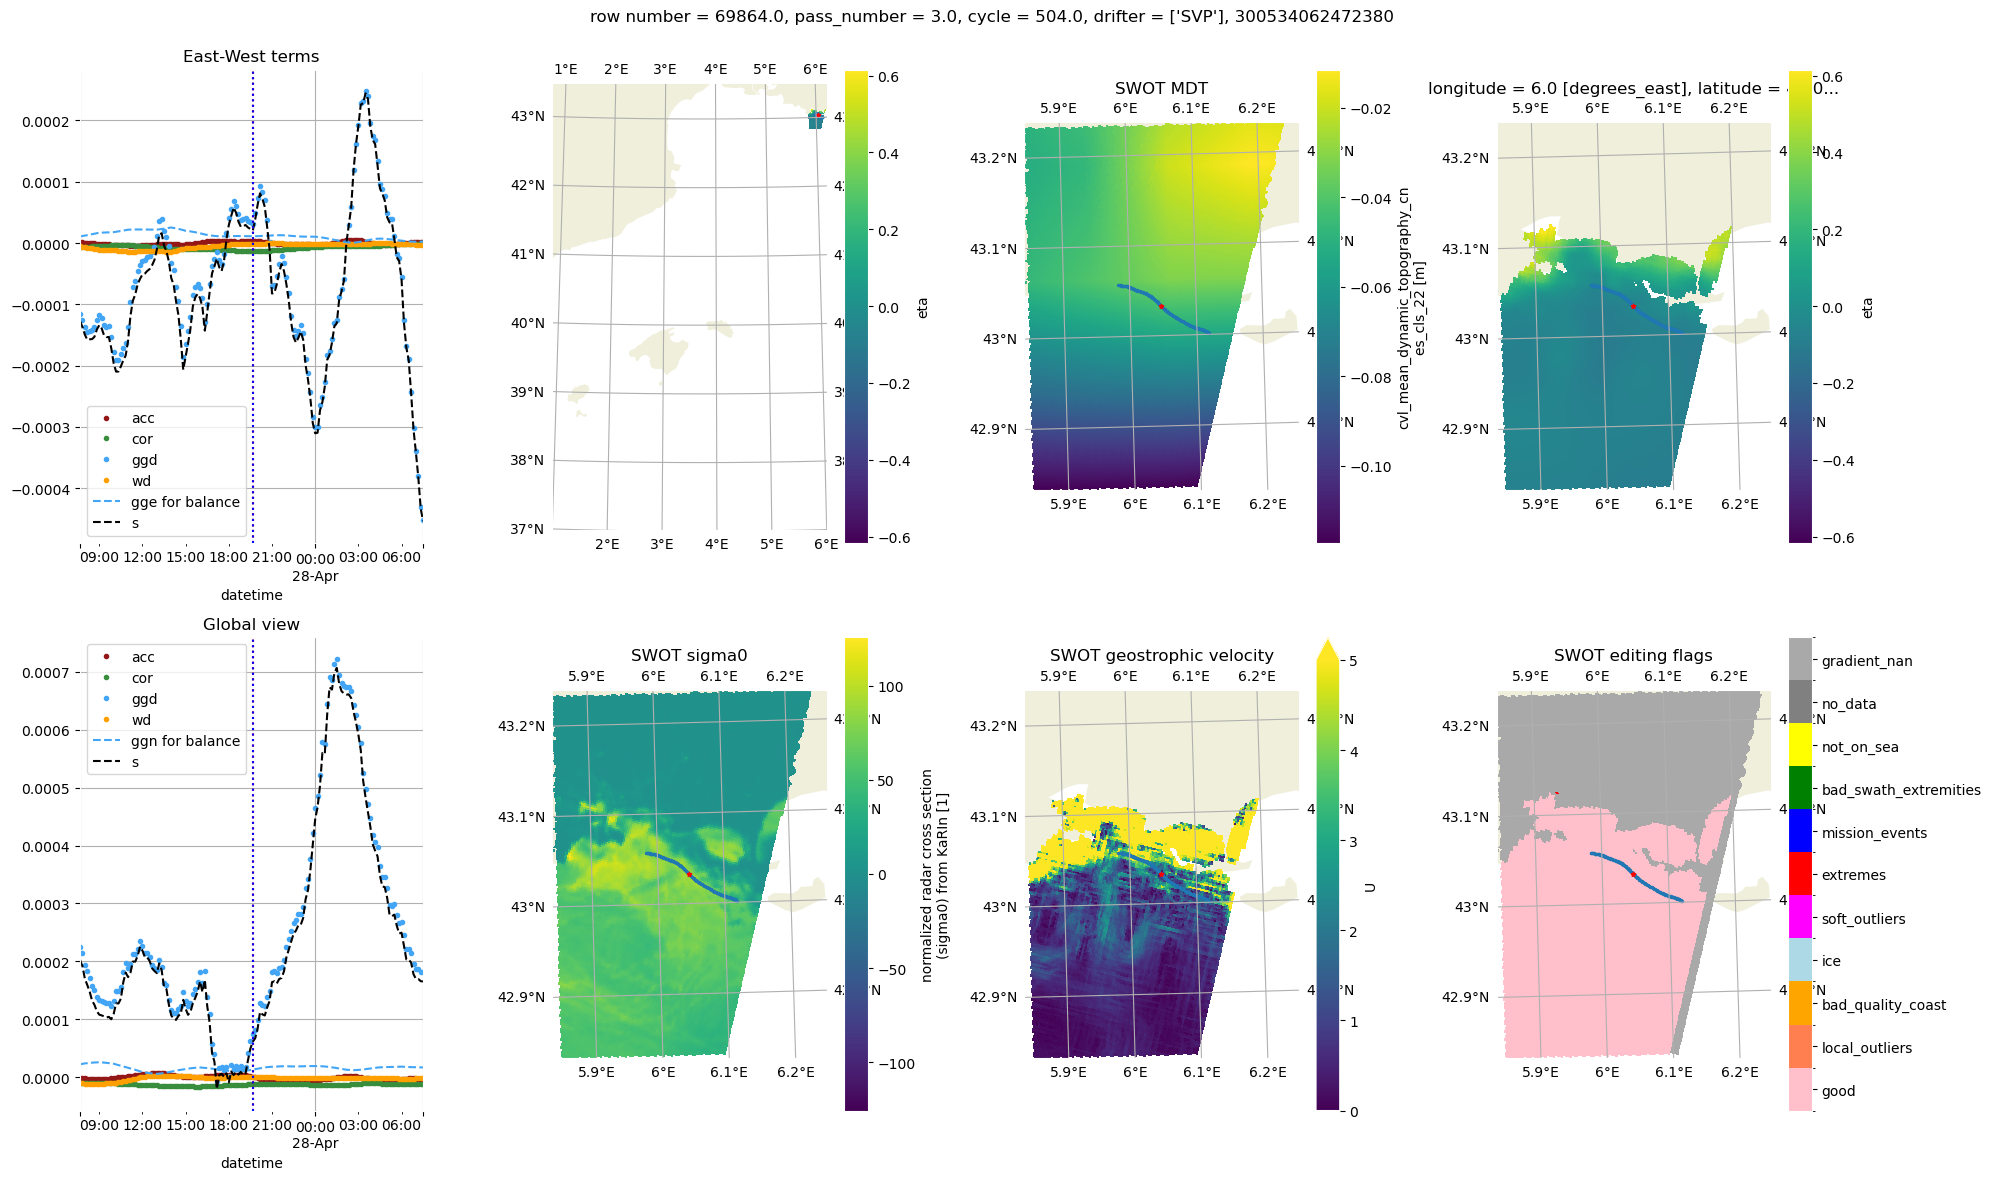

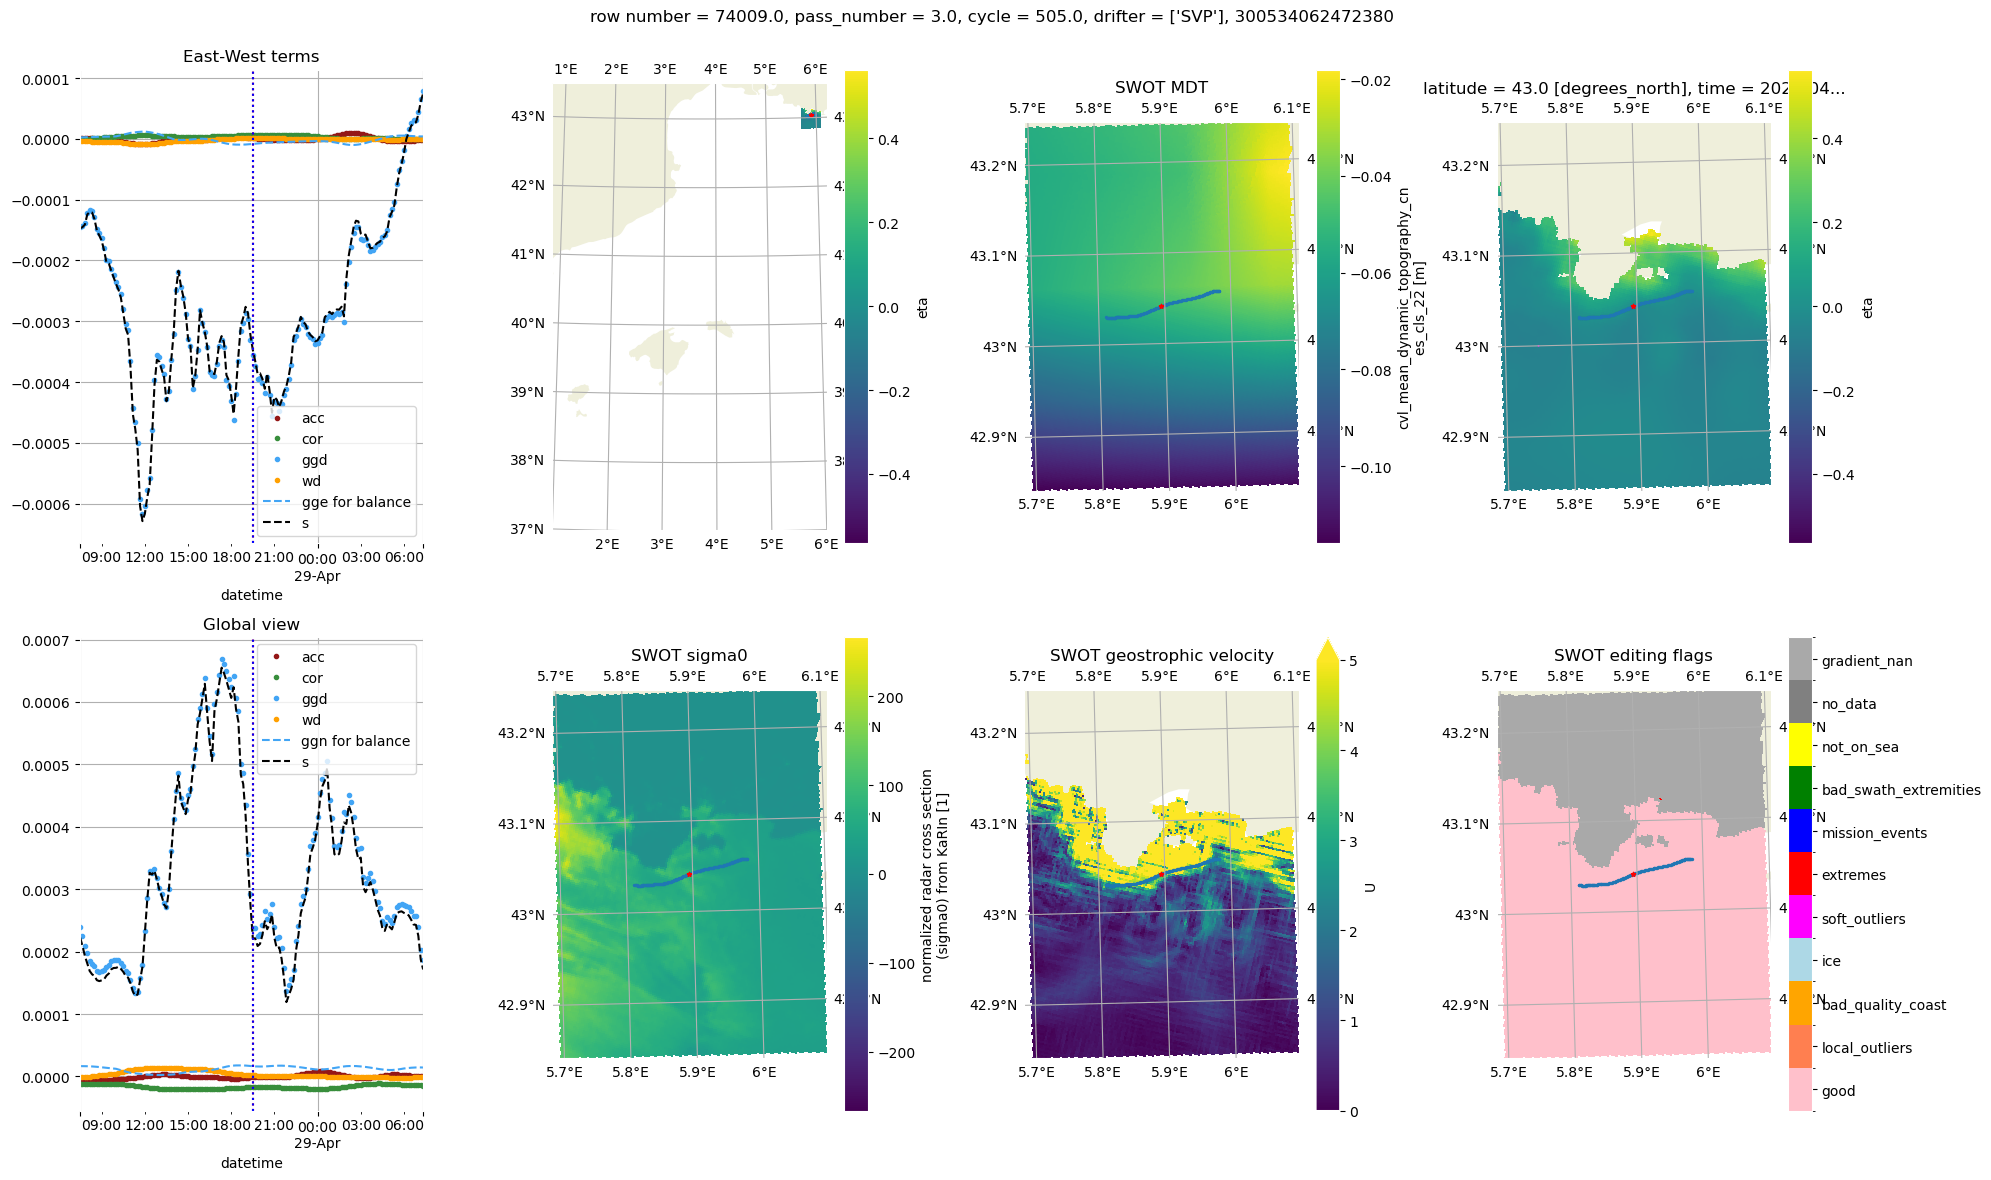

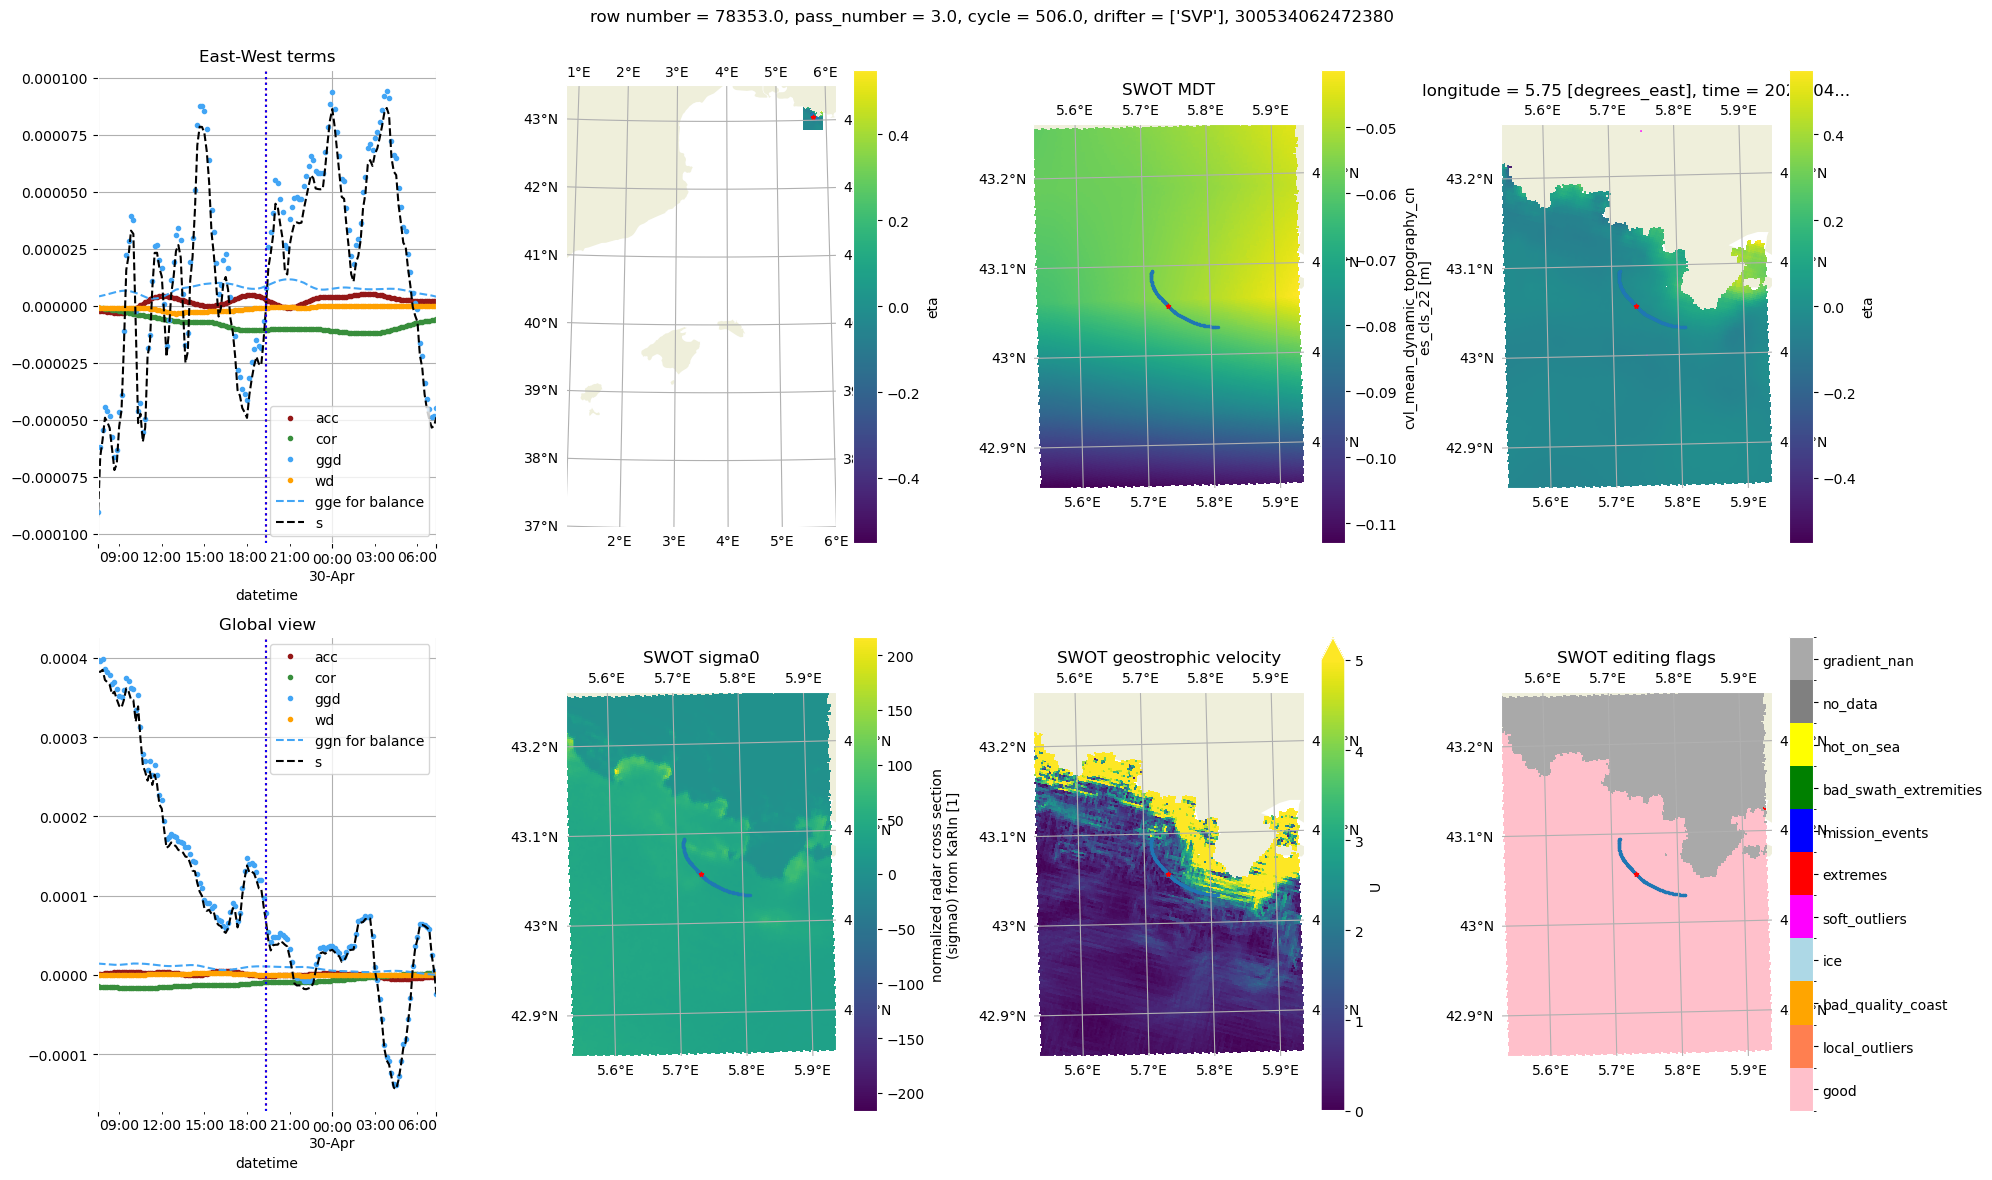

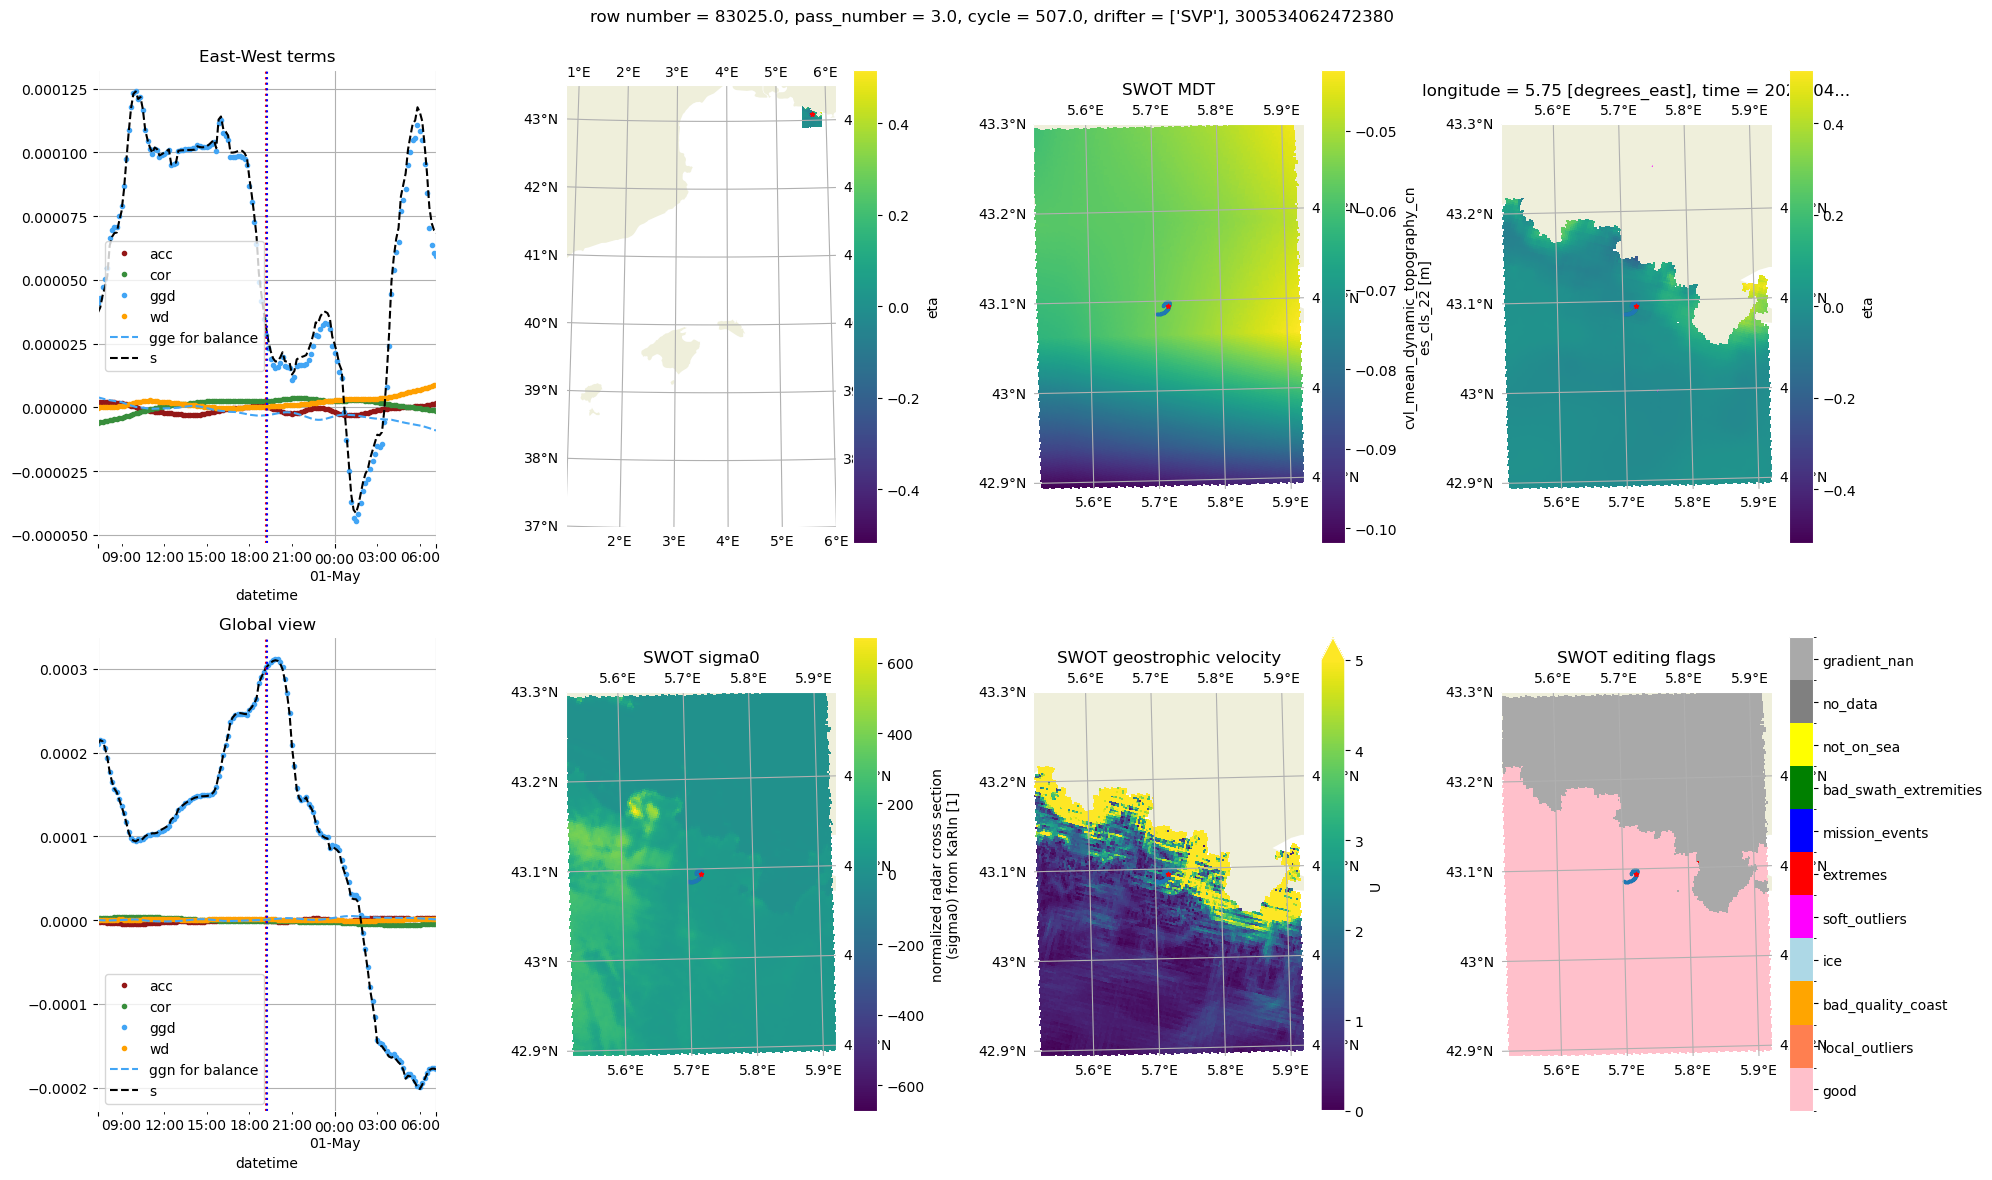

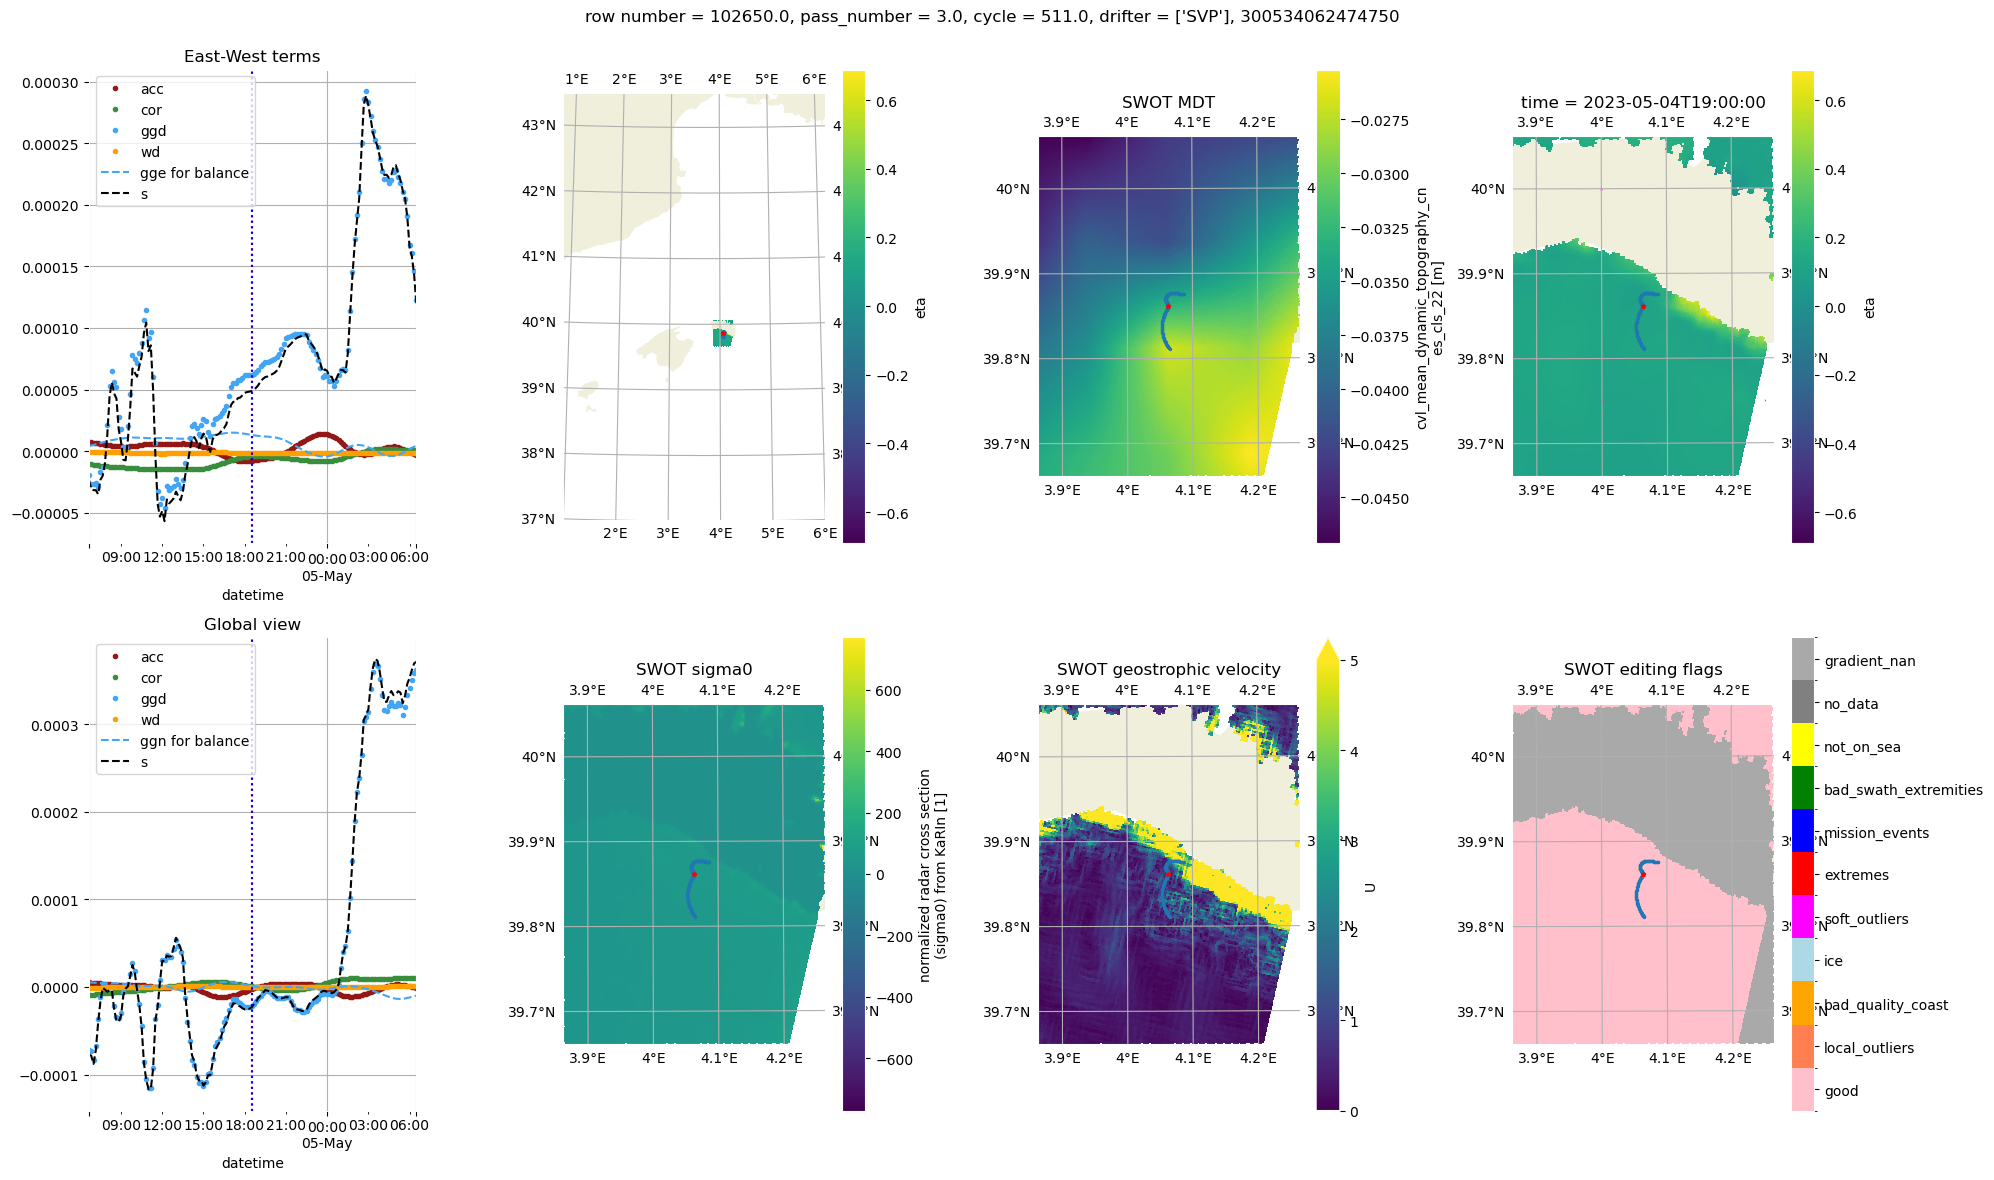

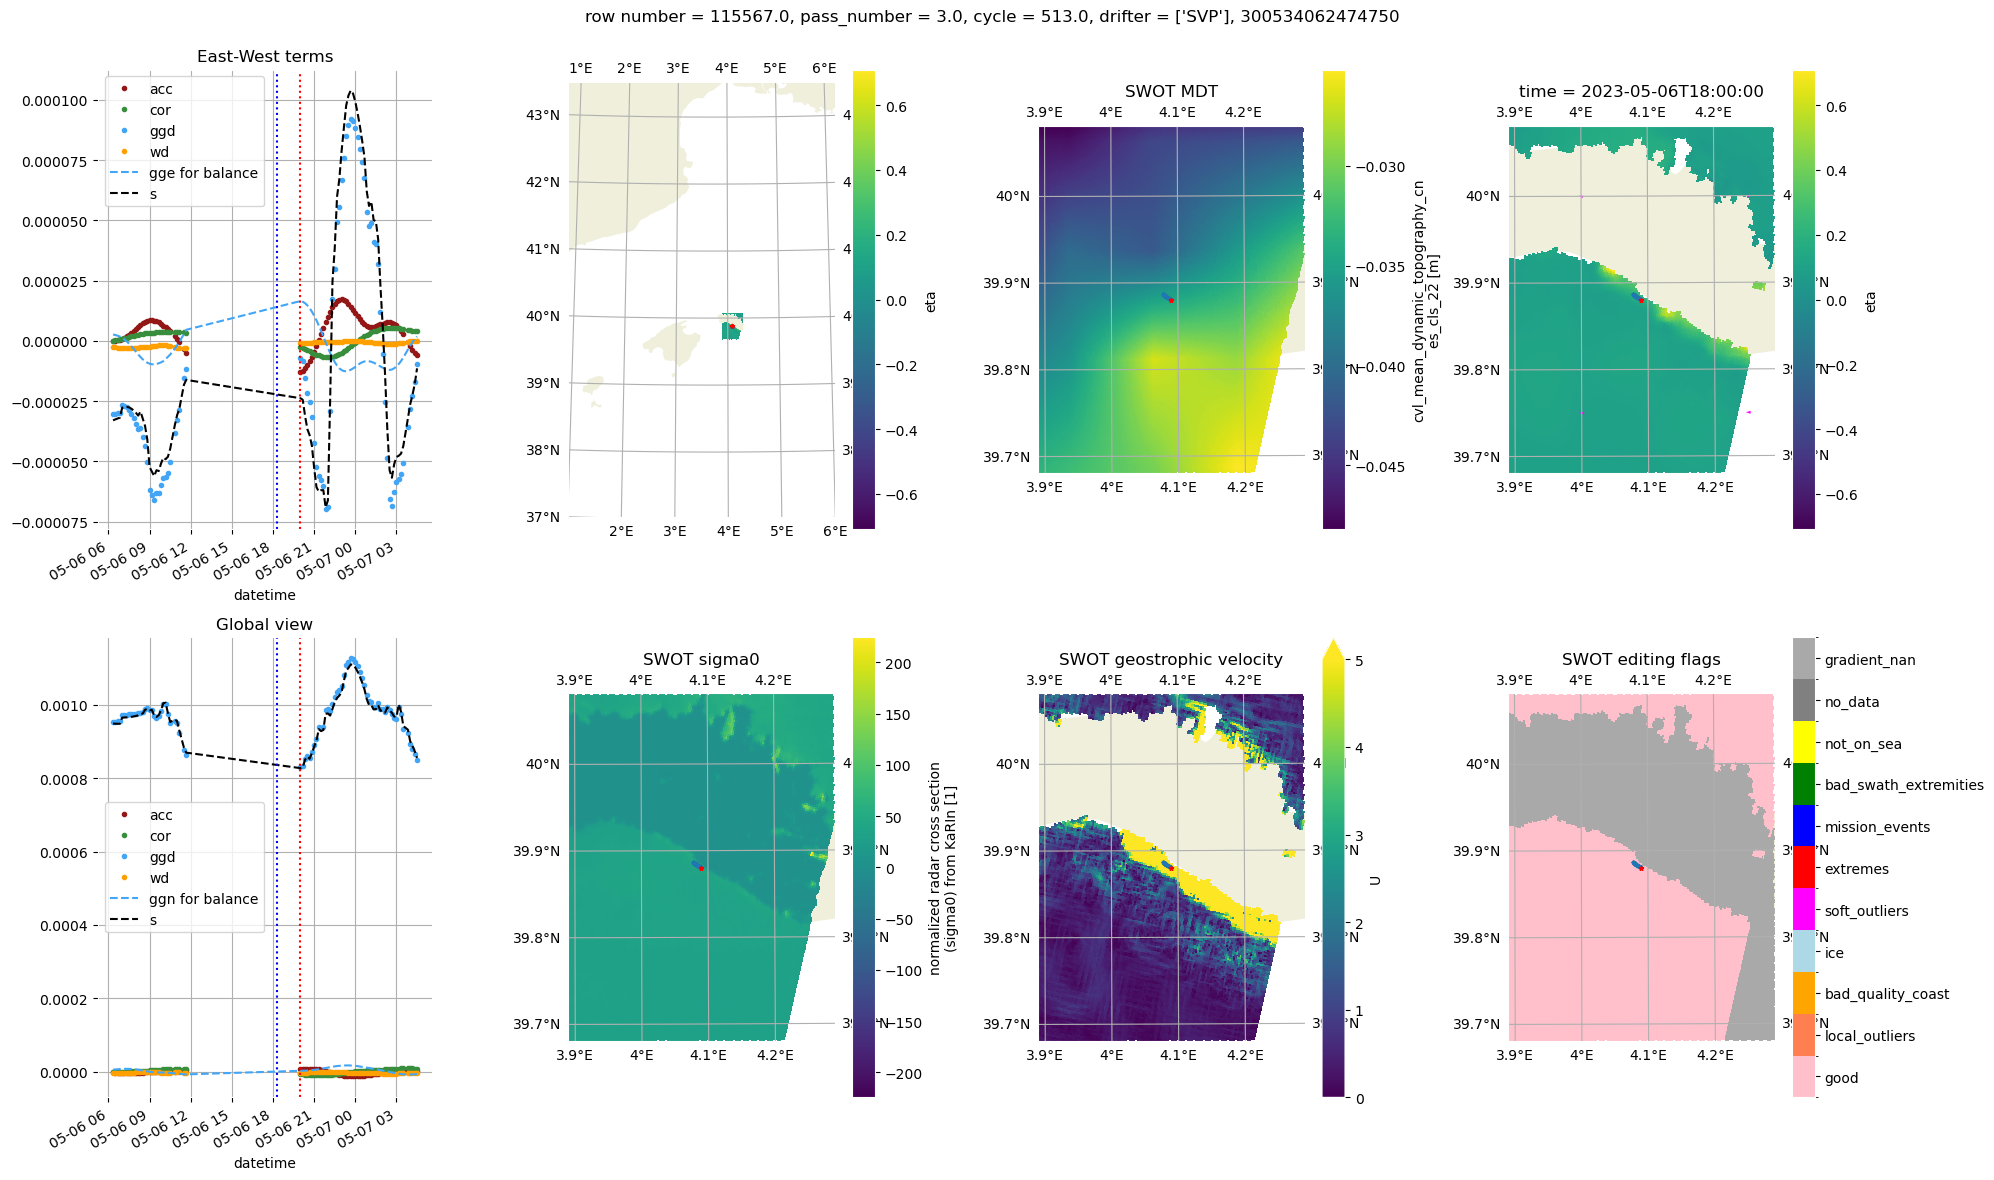

In [ ]:
from diagnosis import select_nearest_swot_coloc

dfpb_ = select_nearest_swot_coloc(dfpb)
index_pb = list(dfpb_.index)

for rn in index_pb:
    plot_exemple(rn, df, "swot250_outliers")

# Are these outliers in SWOT 2km ? NO


In [ ]:
comb_list = [
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    )
]

DS2km = dataset_coloc_combs(comb_list, nearest=False)

In [ ]:
df2km = DS2km.isel(id_comb=0).to_dataframe()
df2kmpb = df2km.take(dfpb.index)

from diagnosis import select_nearest_swot_coloc

df2kmpb_ = select_nearest_swot_coloc(df2kmpb)
index_2kmpb = list(df2kmpb_.index)

for rn in index_pb:
    try:
        plot_exemple(rn, df2km, "swot250outliers_on2km", swot_product="2km")
    except:
        continue

In [ ]:
l = [l for l in list(dfpb.index) if l in list(df2km.index)]
df2km.loc[l]

_______________
# Différence entre les colocs 250m et 2km 

In [ ]:
len(df), len(df2km)

In [ ]:
df_all = df.merge(
    df2km[
        ["pass_number", "longitude", "latitude"]
    ].drop_duplicates(),  # on=['col1','col2'],
    how="left",
    indicator=True,
)

In [ ]:
def select_row(df, pass_number, cycle_number, drifter_id):
    return df.where(
        (df.pass_number == pass_number)
        & (df.cycle_number == cycle_number)
        & (df.drifter_id == drifter_id)
    ).dropna()

In [ ]:
select_row(df2km, 3, 522.0, "300534062474750")

In [45]:
dfonly = df_all[df_all._merge == "left_only"]
dfonly_ = select_nearest_swot_coloc(dfonly)
len(dfonly), len(dfonly_)

(93240, 1266)

In [16]:
len(dfonly_)

17

In [47]:
df_all

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,sume,...,ice,soft_outliers,extremes,mission_events,bad_swath_extremities,not_on_sea,no_data,gradient_nan,cvl_distance_to_coast,_merge
0,2023-04-01 11:50:00,4.811970,42.220893,3.0,0 days 11:52:32.696536,478.0,300534060315840,SVP,15.0,-0.000002,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114000.000000,both
1,2023-04-01 12:00:00,4.812432,42.221430,3.0,0 days 11:42:32.696536,478.0,300534060315840,SVP,15.0,-0.000004,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113940.490247,both
2,2023-04-01 12:10:00,4.812916,42.221930,3.0,0 days 11:32:32.696536,478.0,300534060315840,SVP,15.0,-0.000006,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,113920.969919,both
3,2023-04-01 12:20:00,4.813418,42.222394,3.0,0 days 11:22:32.696536,478.0,300534060315840,SVP,15.0,-0.000009,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,113758.848724,both
4,2023-04-01 12:30:00,4.813933,42.222825,3.0,0 days 11:12:32.696536,478.0,300534060315840,SVP,15.0,-0.000009,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113572.617334,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383258,2023-07-10 06:10:00,2.417785,39.788394,16.0,0 days 11:13:38.131544384,577.0,300534060015760,SVP,15.0,0.000015,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13063.591430,both
383259,2023-07-10 06:20:00,2.416881,39.788885,16.0,0 days 11:23:38.131544384,577.0,300534060015760,SVP,15.0,0.000018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13245.561986,both
383260,2023-07-10 06:30:00,2.415948,39.789399,16.0,0 days 11:33:38.131544384,577.0,300534060015760,SVP,15.0,0.000019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13765.739505,both
383261,2023-07-10 06:40:00,2.414994,39.789938,16.0,0 days 11:43:38.131544384,577.0,300534060015760,SVP,15.0,0.000020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13973.404159,both


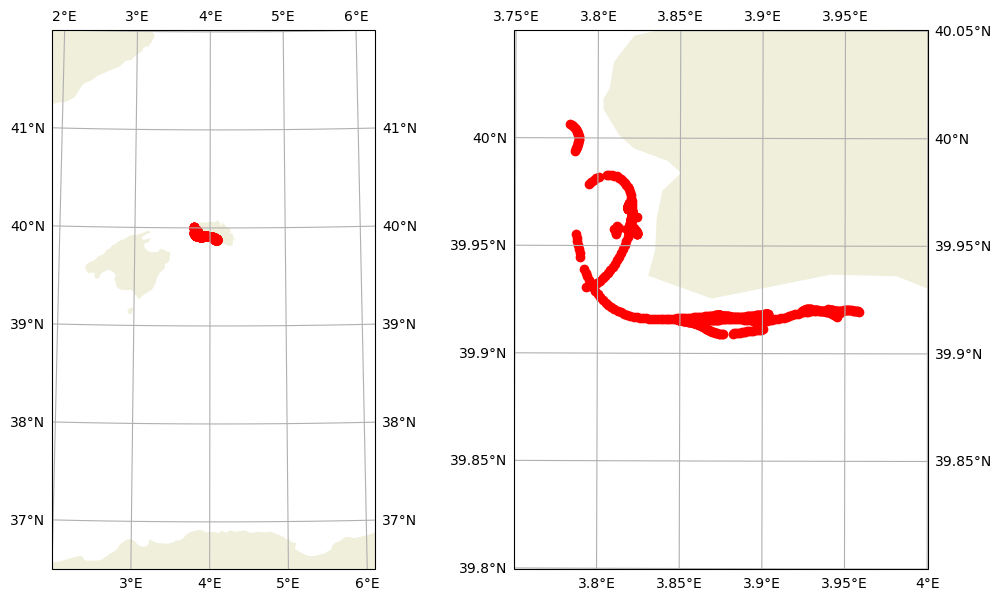

In [7]:
fig = plt.figure(figsize=(12, 7), frameon=False)

ax = fig.add_subplot(
    121, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean())
)
# a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [2, 6.1, 36.5, 42]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform=crs, c="r")
ax.set_extent(bbox)
ax.add_feature(
    cfeature.LAND,
)

gl = ax.gridlines(
    draw_labels=True,
)
gl.xlabels_top = False
gl.ylabels_right = False


ax = fig.add_subplot(
    122, projection=ccrs.Orthographic(dfpb.longitude.mean(), dfpb.latitude.mean())
)
# a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
bbox = [3.75, 4, 39.8, 40.05]
a = ax.scatter(dfpb.longitude, dfpb.latitude, transform=crs, c="r")
ax.set_extent(bbox)
ax.add_feature(
    cfeature.LAND,
)

gl = ax.gridlines(
    draw_labels=True,
)
gl.xlabels_top = False
gl.ylabels_right = False